In [ ]:
#============Spark Initialisation====================
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CrimeArrestPrediction") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

In [ ]:
#=======Define Schema + Load Data================
#firstly, to define the structure of the data, we import these data types
from pyspark.sql.types import *
schema = StructType([
    StructField("ID", LongType(), True),
    StructField("Case Number", StringType(), True),
    StructField("Date", StringType(), True),
    StructField("Block", StringType(), True),
    StructField("IUCR", StringType(), True),
    StructField("Primary Type", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Location Description", StringType(), True),
    StructField("Arrest", BooleanType(), True),
    StructField("Domestic", BooleanType(), True),
    StructField("Beat", IntegerType(), True),
    StructField("District", IntegerType(), True),
    StructField("Ward", IntegerType(), True),
    StructField("Community Area", IntegerType(), True),
    StructField("FBI Code", StringType(), True),
    StructField("X Coordinate", DoubleType(), True),
    StructField("Y Coordinate", DoubleType(), True),
    StructField("Year", IntegerType(), True),
    StructField("Latitude", DoubleType(), True),
    StructField("Longitude", DoubleType(), True),
    StructField("Location", StringType(), True),
    StructField("Updated On", StringType(), True)
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#the raw data is imported for the location
#(since mine was in google drive, it had to be imported as seen above)
file_path = "/content/drive/MyDrive/Crimes_-_2001_to_Present (2).csv"


In [ ]:
df = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
)

print("Initial count:", df.count())

Initial count: 8493086


In [ ]:
#Convert CSV to Parquet

parquet_path = "/content/chicago_crime_parquet"

# Write to Parquet (overwrite to avoid duplicate errors)
df.write.mode("overwrite").parquet(parquet_path)

# Reload dataset from Parquet
df = spark.read.parquet(parquet_path)

print("Parquet conversion completed successfully.")
df.printSchema()

Parquet conversion completed successfully.
root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)



In [ ]:
# ====================== Data Cleaning =====================
from pyspark.sql.functions import col, to_timestamp, hour, dayofweek, month, when

# Convert date
df = df.withColumn(
    "Date",
    to_timestamp("Date", "MM/dd/yyyy hh:mm:ss a")
)

# Extract time features
df = df.withColumn("Hour", hour("Date")) \
       .withColumn("DayOfWeek", dayofweek("Date")) \
       .withColumn("Month", month("Date")) \
       .withColumn(
           "IsWeekend",
           when(col("DayOfWeek").isin([1,7]), 1).otherwise(0)
       )

# Drop irrelevant columns
df = df.drop(
    "Case Number",
    "Updated On",
    "Location",
    "X Coordinate",
    "Y Coordinate",
    "ID",
    "Block",
    "Description",
    "IUCR",
    "FBI Code"
)

# Drop rows missing coordinates ONLY
df = df.dropna(subset=["Latitude", "Longitude"])

# Fill missing values
df = df.fillna({
    "District": -1,
    "Ward": -1,
    "Community Area": -1,
    "Beat": -1,
    "Domestic": 0,
    "Location Description": "Unknown"
})

# Create label
df = df.withColumn("label", col("Arrest").cast("integer"))

# Drop original Arrest column
df = df.drop("Arrest")

# Define numeric columns AFTER label exists
numeric_cols = [
    "Beat",
    "District",
    "Ward",
    "Community Area",
    "Latitude",
    "Longitude",
    "Year",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "label"
]

print("After cleaning:", df.count())

After cleaning: 8398481


In [ ]:
from pyspark.sql.functions import sum
df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in numeric_cols
]).show()

+----+--------+----+--------------+--------+---------+----+----+---------+-----+---------+-----+
|Beat|District|Ward|Community Area|Latitude|Longitude|Year|Hour|DayOfWeek|Month|IsWeekend|label|
+----+--------+----+--------------+--------+---------+----+----+---------+-----+---------+-----+
|   0|       0|   0|             0|       0|        0|   0|   0|        0|    0|        0|    0|
+----+--------+----+--------------+--------+---------+----+----+---------+-----+---------+-----+



In [ ]:
#============Feature Engineering==============================
# this section converts the data into numerical format for easier understanding
#by machine learning algoritms
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

In [ ]:
categorical_cols = [
    "Primary Type",
    "Location Description"
]

numeric_cols = [
    "District",
    "Community Area",
    "Beat",
    "Domestic",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "Latitude",
    "Longitude"
]

In [ ]:
indexers = [
    StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )
    for col_name in categorical_cols
]

In [ ]:
encoder = OneHotEncoder(
    inputCols=[col + "_index" for col in categorical_cols],
    outputCols=[col + "_vec" for col in categorical_cols]
)

In [ ]:
assembler = VectorAssembler(
    inputCols=[col + "_vec" for col in categorical_cols] + numeric_cols,
    outputCol="features"
)

In [ ]:
#=========Train/Test Split================
# this code allows the learning and evaluation of the datset (train) and through this,
#the prediction of an outcome based on the context of the dataset (test)
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

train_df.cache()
test_df.cache()

print("Train:", train_df.count())
print("Test:", test_df.count())

Train: 6717953
Test: 1680528


In [ ]:
train_df.select("Primary Type").distinct().count()

34

In [ ]:
# ====================== Evaluation ======================
# This section makes use of classification algorithms to evaluate the performance of the trained
# and tested model

from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_model(predictions):

    # ROC-AUC
    evaluator_roc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    # Accuracy
    evaluator_accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    )

    # F1 Score
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    )

    return {
        "ROC-AUC": evaluator_roc.evaluate(predictions),
        "Accuracy": evaluator_accuracy.evaluate(predictions),
        "F1": evaluator_f1.evaluate(predictions)
    }

In [ ]:
# Logistic Regression

from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
import time

lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=100
)

lr_pipeline = Pipeline(
    stages=indexers + [encoder, assembler, lr]
)

start_time = time.time()
lr_model = lr_pipeline.fit(train_df)
spark_lr_training_time = time.time() - start_time

print("Spark Logistic Regression Training Time:", spark_lr_training_time)

lr_predictions = lr_model.transform(test_df)

lr_metrics = evaluate_model(lr_predictions)

print("Logistic Regression Results:")
print(lr_metrics)

Spark Logistic Regression Training Time: 146.20636868476868
Logistic Regression Results:
{'ROC-AUC': 0.8712739040128141, 'Accuracy': 0.8657386250035704, 'F1': 0.8540515681938682}


In [ ]:
# sklearn Baseline

from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import time

# Transform training data using Spark pipeline
lr_train_transformed = lr_model.transform(train_df)

# Sample small subset for sklearn (avoid memory crash)
sk_sample = lr_train_transformed.select("features", "label").sample(fraction=0.02, seed=42)
sk_sample_pd = sk_sample.toPandas()

X = np.vstack(sk_sample_pd["features"].apply(lambda x: x.toArray()))
y = sk_sample_pd["label"]

# Train sklearn model
start_time = time.time()

sk_model = SkLogisticRegression(max_iter=500, solver="saga")
sk_model.fit(X, y)

sk_training_time = time.time() - start_time

# Evaluate sklearn
sk_probs = sk_model.predict_proba(X)[:, 1]
sk_roc = roc_auc_score(y, sk_probs)

print("sklearn Logistic Regression ROC-AUC:", sk_roc)
print("sklearn Training Time:", sk_training_time)

sklearn Logistic Regression ROC-AUC: 0.7957733482076195
sklearn Training Time: 386.5968916416168


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
#Decision Tree

from pyspark.ml.classification import DecisionTreeClassifier
import time  # Only if not already imported earlier

dt = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    maxDepth=10,
    seed=42
)

dt_pipeline = Pipeline(
    stages=indexers + [encoder, assembler, dt]
)

start_time = time.time()
dt_model = dt_pipeline.fit(train_df)
spark_dt_training_time = time.time() - start_time

print("Decision Tree Training Time:", spark_dt_training_time)

dt_predictions = dt_model.transform(test_df)

dt_metrics = evaluate_model(dt_predictions)

print("Decision Tree Results:")
print(dt_metrics)

Decision Tree Training Time: 508.73112082481384
Decision Tree Results:
{'ROC-AUC': 0.24828080569833716, 'Accuracy': 0.8726382422667162, 'F1': 0.8616427948956202}


In [ ]:
# Gradient Boosted Trees

from pyspark.ml.classification import GBTClassifier

# Controlled sampling for computational feasibility
gbt_train_sample = train_df.sample(fraction=0.15, seed=42)

gbt = GBTClassifier(
    labelCol="label",
    featuresCol="features",
    maxIter=10,      # reduced from 20
    maxDepth=4,      # reduced from 5
    seed=42
)

gbt_pipeline = Pipeline(
    stages=indexers + [encoder, assembler, gbt]
)

start_time = time.time()
gbt_model = gbt_pipeline.fit(gbt_train_sample)
spark_gbt_training_time = time.time() - start_time
print("Gradient Boosted Trees Training Time:", spark_lr_training_time)

gbt_predictions = gbt_model.transform(test_df)

# Cache predictions to prevent recomputation during metric evaluation
gbt_predictions.cache()
gbt_predictions.count()

gbt_metrics = evaluate_model(gbt_predictions)

print("Gradient Boosted Trees Results:")
print(gbt_metrics)

Gradient Boosted Trees Training Time: 146.20636868476868
Gradient Boosted Trees Results:
{'ROC-AUC': 0.8493506249353352, 'Accuracy': 0.867384536288595, 'F1': 0.8529945825874787}


In [ ]:
#Random Forest

from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=50,
    maxDepth=10,
    seed=42
)

rf_pipeline = Pipeline(
    stages=indexers + [encoder, assembler, rf]
)

start_time = time.time()
rf_model = rf_pipeline.fit(train_df)
spark_rf_training_time = time.time() - start_time
print("Random Forest Training Time:", spark_rf_training_time)

rf_predictions = rf_model.transform(test_df)

rf_metrics = evaluate_model(rf_predictions)

print("Random Forest Results:")
print(rf_metrics)

Random Forest Training Time: 1756.1602773666382
Random Forest Results:
{'ROC-AUC': 0.8630681001573628, 'Accuracy': 0.8483512324697952, 'F1': 0.8232536221522091}


In [ ]:
lr_metrics = evaluate_model(lr_predictions)
print("Logistic Regression Results:")
print("ROC-AUC:", lr_metrics["ROC-AUC"])
print("Accuracy:", lr_metrics["Accuracy"])
print("F1 Score:", lr_metrics["F1"])

Logistic Regression Results:
ROC-AUC: 0.8712734648339344
Accuracy: 0.8657386250035704
F1 Score: 0.8540515681938682


In [ ]:
rf_metrics = evaluate_model(rf_predictions)
print("Random Forest Results:")
print("ROC-AUC:", rf_metrics["ROC-AUC"])
print("Accuracy:", rf_metrics["Accuracy"])
print("F1 Score:", rf_metrics["F1"])

Random Forest Results:
ROC-AUC: 0.8630700493297826
Accuracy: 0.8483512324697952
F1 Score: 0.8232536221522091


In [ ]:
dt_metrics = evaluate_model(dt_predictions)
print("Decision Tree Results:")
print("ROC-AUC:", dt_metrics["ROC-AUC"])
print("Accuracy:", dt_metrics["Accuracy"])
print("F1 Score:", dt_metrics["F1"])

Decision Tree Results:
ROC-AUC: 0.24828080569833716
Accuracy: 0.8726382422667162
F1 Score: 0.8616427948956202


In [ ]:
gbt_metrics = evaluate_model(gbt_predictions)
print("Gradient boosted tree Results:")
print("ROC-AUC:", gbt_metrics["ROC-AUC"])
print("Accuracy:", gbt_metrics["Accuracy"])
print("F1 Score:", gbt_metrics["F1"])

Gradient boosted tree Results:
ROC-AUC: 0.8493506249353352
Accuracy: 0.867384536288595
F1 Score: 0.8529945825874787


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "GBT"],
    "ROC-AUC": [
        lr_metrics["ROC-AUC"],
        rf_metrics["ROC-AUC"],
        dt_metrics["ROC-AUC"],
        gbt_metrics["ROC-AUC"]
    ],
    "Accuracy": [
        lr_metrics["Accuracy"],
        rf_metrics["Accuracy"],
        dt_metrics["Accuracy"],
        gbt_metrics["Accuracy"]
    ],
    "F1": [
        lr_metrics["F1"],
        rf_metrics["F1"],
        dt_metrics["F1"],
        gbt_metrics["F1"]
    ]
})

results_df

,Model,ROC-AUC,Accuracy,F1
0,Logistic Regression,0.871273,0.865739,0.854052
1,Random Forest,0.863070,0.848351,0.823254
2,Decision Tree,0.248281,0.872638,0.861643
3,GBT,0.849351,0.867385,0.852995


In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

cv_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [ ]:
# ===================== Stability Testing =====================

seeds = [10, 42, 100]
stability_results = []

for seed in seeds:
    train_temp, test_temp = df.randomSplit([0.8, 0.2], seed=seed)

    lr_temp = lr_pipeline.fit(train_temp)
    preds_temp = lr_temp.transform(test_temp)

    roc_temp = evaluate_model(preds_temp)["ROC-AUC"]

    print(f"Seed {seed} ROC-AUC:", roc_temp)
    stability_results.append(roc_temp)

Seed 10 ROC-AUC: 0.871399234394623
Seed 42 ROC-AUC: 0.8712739526725154
Seed 100 ROC-AUC: 0.871003756958696


In [ ]:
# ===================== Scalability Timing =====================

fractions = [0.2, 0.4, 0.6]
scalability_times = []

for frac in fractions:
    sample_train = train_df.sample(fraction=frac, seed=42)

    start_time = time.time()
    _ = lr_pipeline.fit(sample_train)
    elapsed = time.time() - start_time

    print(f"Training time for {int(frac*100)}% data:", elapsed)
    scalability_times.append(elapsed)

Training time for 20% data: 40.381197690963745
Training time for 40% data: 62.03021001815796
Training time for 60% data: 84.26792454719543


In [ ]:
#===============Cross Validation===================

from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.0, 0.01, 0.1])
             .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
             .build())

crossval = CrossValidator(
    estimator=lr_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=cv_evaluator,   # FIXED
    numFolds=3
)

cv_model = crossval.fit(train_df)

best_model = cv_model.bestModel

tuned_predictions = best_model.transform(test_df)

print("Tuned ROC:", cv_evaluator.evaluate(tuned_predictions))

Tuned ROC: 0.8712734493644838


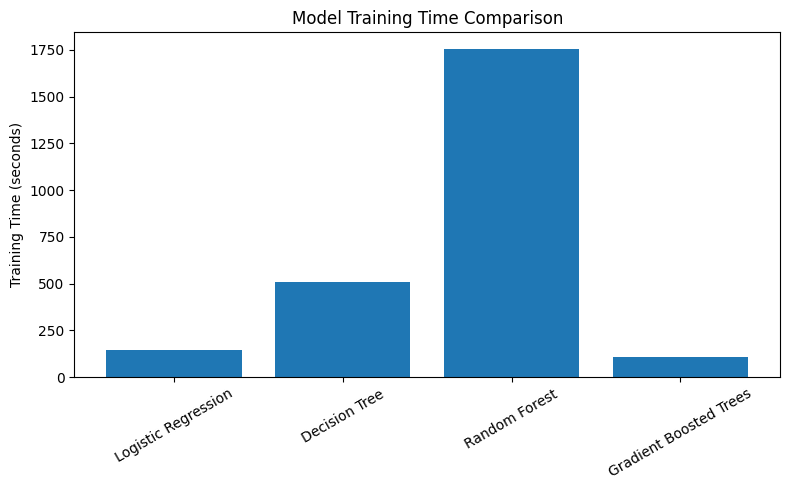

,Model,Training Time (seconds)
0,Logistic Regression,146.206369
1,Decision Tree,508.731121
2,Random Forest,1756.160277
3,Gradient Boosted Trees,105.369587


In [ ]:
# ===================== Runtime Comparison Plot =====================

import matplotlib.pyplot as plt
import pandas as pd

runtime_data = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosted Trees"
    ],
    "Training Time (seconds)": [
        spark_lr_training_time,
        spark_dt_training_time,
        spark_rf_training_time,
        spark_gbt_training_time
    ]
})

plt.figure(figsize=(8,5))
plt.bar(runtime_data["Model"], runtime_data["Training Time (seconds)"])
plt.xticks(rotation=30)
plt.ylabel("Training Time (seconds)")
plt.title("Model Training Time Comparison")
plt.tight_layout()
plt.show()

runtime_data

In [ ]:
#=======================Tableau Export Datasets================
# Tableau Dataset 1: Yearly Arrest Rate

from pyspark.sql.functions import avg

yearly_summary = df.groupBy("Year").agg(
    avg("label").alias("Arrest_Rate")
)

yearly_summary = yearly_summary.orderBy("Year")

yearly_summary.toPandas().to_csv(
    "yearly_arrest_rate.csv",
    index=False
)

print("Yearly arrest dataset exported.")


Yearly arrest dataset exported.


In [ ]:
# Tableau Dataset 2: Crime Type Arrest Rate

crime_type_summary = df.groupBy("Primary Type").agg(
    avg("label").alias("Arrest_Rate")
)

crime_type_summary = crime_type_summary.orderBy(
    "Arrest_Rate", ascending=False
)

crime_type_summary.toPandas().to_csv(
    "crime_type_arrest_rate.csv",
    index=False
)

print("Crime type arrest dataset exported.")

Crime type arrest dataset exported.


In [ ]:
# Tableau Dataset 3: Hourly Arrest Rate
hourly_summary = df.groupBy("Hour").agg(
    avg("label").alias("Arrest_Rate")
)

hourly_summary = hourly_summary.orderBy("Hour")

hourly_summary.toPandas().to_csv(
    "hourly_arrest_rate.csv",
    index=False
)

print("Hourly arrest dataset exported.")

Hourly arrest dataset exported.


In [ ]:
# Tableau Dataset 4: Location Arrest Rate

from pyspark.sql.functions import count

location_summary = df.groupBy("Location Description").agg(
    count("*").alias("Total_Cases"),
    avg("label").alias("Arrest_Rate")
)

# Filter out small-sample locations
filtered_locations = location_summary.filter(
    location_summary.Total_Cases >= 1000
)

filtered_locations = filtered_locations.orderBy(
    "Arrest_Rate", ascending=False
)

filtered_locations.toPandas().to_csv(
    "location_arrest_rate.csv",
    index=False
)

print("Location arrest dataset exported.")

Location arrest dataset exported.
